## Factorial Program: Iterative vs. Recursive Implementation and Time Analysis

### 1. Iterative Factorial Implementation

This method uses a loop to calculate the factorial, multiplying numbers from 1 up to the given number `n`.

In [ ]:
def factorial_iterative(n):
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers.")
    if n == 0:
        return 1
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result

print(f"Iterative factorial of 5: {factorial_iterative(5)}")

Iterative factorial of 5: 120


### 2. Recursive Factorial Implementation

This method defines the factorial of `n` in terms of the factorial of `n-1`, with a base case for `n=0` or `n=1`.

In [ ]:
def factorial_recursive(n):
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers.")
    if n == 0 or n == 1:
        return 1
    else:
        return n * factorial_recursive(n - 1)

print(f"Recursive factorial of 5: {factorial_recursive(5)}")

Recursive factorial of 5: 120


### 3. Time Analysis

We will use the `timeit` module to measure the execution time of both implementations for various input sizes. This helps us understand their performance characteristics.

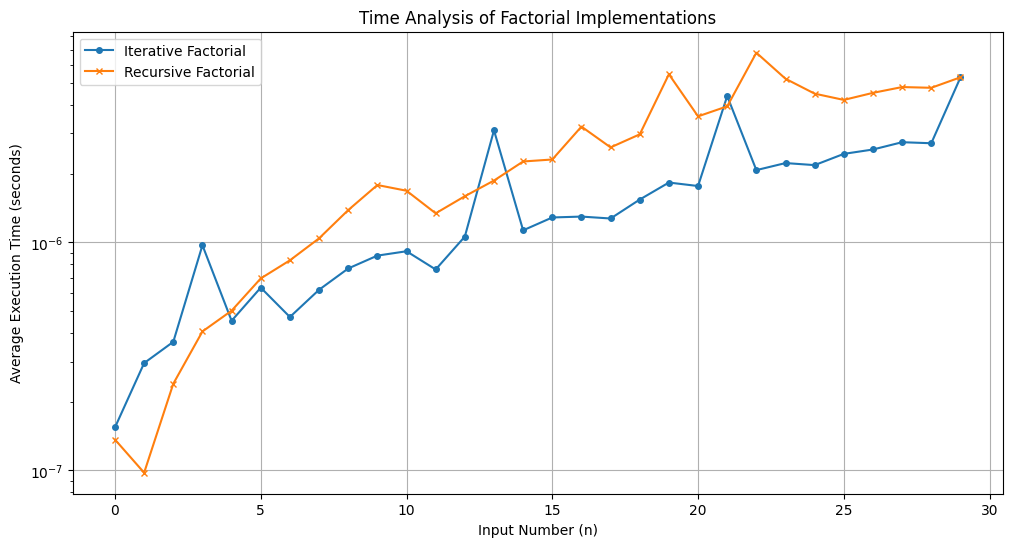

In [ ]:
import timeit
import matplotlib.pyplot as plt

def run_analysis(func, max_n):
    times = []
    for n in range(max_n):
        # Use a larger number of repetitions for more accurate measurements
        # but keep it low enough to not take too long
        number_of_runs = 1000
        if n > 10:
            number_of_runs = 100
        if n > 20:
            number_of_runs = 10

        # Setup for timeit to ensure the function is defined in its scope
        setup_code = f"from __main__ import {func.__name__}"
        stmt = f"{func.__name__}({n})"

        try:
            t = timeit.timeit(stmt, setup=setup_code, number=number_of_runs)
            times.append(t / number_of_runs) # Store average time per run
        except RecursionError:
            print(f"Recursion depth exceeded for {func.__name__}({n})")
            times.append(float('nan')) # Mark as NaN if recursion error occurs
        except Exception as e:
            print(f"Error with {func.__name__}({n}): {e}")
            times.append(float('nan'))
    return times

max_input = 30 # You can adjust this to test larger numbers

iterative_times = run_analysis(factorial_iterative, max_input)
recursive_times = run_analysis(factorial_recursive, max_input)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(max_input), iterative_times, label='Iterative Factorial', marker='o', markersize=4)
plt.plot(range(max_input), recursive_times, label='Recursive Factorial', marker='x', markersize=4)

plt.xlabel('Input Number (n)')
plt.ylabel('Average Execution Time (seconds)')
plt.title('Time Analysis of Factorial Implementations')
plt.legend()
plt.grid(True)
plt.yscale('log') # Use log scale for y-axis to better visualize differences if times vary widely
plt.show()

### Analysis Summary

From the plot, you can observe how the execution time for both iterative and recursive approaches scales with the input number `n`.

*   **Iterative:** Typically shows a more linear and stable performance as it directly controls the loop, avoiding the overhead of function calls.
*   **Recursive:** While elegant, recursive calls involve overhead (stack frames, function call setup/teardown) which can lead to slower performance for larger `n` and potentially hit Python's recursion limit much earlier than the iterative approach would hit memory limits.

For very large numbers, Python's default recursion limit (usually 1000) will be hit, causing a `RecursionError` for the recursive function. The iterative version can handle much larger numbers before hitting integer overflow or memory limits, depending on the system.